In [ ]:
from graphviz import Digraph

# Création du diagramme
bpmn = Digraph('Traspex_Process', format='png')
bpmn.attr(rankdir='LR', size='12')

# Styles
bpmn.attr('node', shape='rectangle', style='filled', color='lightblue')

# Début
bpmn.node('Start', 'Début\nMatière brute (50 cm)', shape='circle', color='green')

# Phase 1 : Extraction
bpmn.node('C1', 'Concassage\n50cm → 10cm')
bpmn.node('B2', 'Broyage\n10cm → 2cm')
bpmn.node('SMM3', 'Sand Making\n2cm → 4mm')
bpmn.node('Crib', 'Criblage\n4mm → 2mm', shape='diamond', color='orange')

# Rejet
bpmn.node('Rejet', 'Re-broyage', color='red')

# Phase AKW
bpmn.node('AKW', 'Lavage AKW\nSLH20')
bpmn.node('DecAKW', '0.1 - 0.7 mm ?', shape='diamond', color='orange')

# Expédition directe
bpmn.node('ExpVrac', 'Expédition Vrac', shape='oval', color='green')

# GKM
bpmn.node('GKM', 'Fractionnement GKM')

# Produits
bpmn.node('SLH30', 'SLH30')
bpmn.node('SM10', 'SM10')
bpmn.node('ISM2', 'ISM2')
bpmn.node('SM80', 'SM80')
bpmn.node('SM30', 'SM30')

# Micronisation
bpmn.node('Micro', 'Micronisation')
bpmn.node('SLM60', 'SLM60 <0.063mm')
bpmn.node('BigBag', 'Mise en Big Bag')
bpmn.node('ExpFinal', 'Expédition Finale', shape='oval', color='green')

# Fin
bpmn.node('End', 'Client', shape='doublecircle', color='blue')

# Connexions
bpmn.edge('Start', 'C1')
bpmn.edge('C1', 'B2')
bpmn.edge('B2', 'SMM3')
bpmn.edge('SMM3', 'Crib')

# Décision criblage
bpmn.edge('Crib', 'Rejet', label='>2mm')
bpmn.edge('Rejet', 'B2')
bpmn.edge('Crib', 'AKW', label='<2mm')

# AKW
bpmn.edge('AKW', 'DecAKW')
bpmn.edge('DecAKW', 'ExpVrac', label='Oui')
bpmn.edge('DecAKW', 'GKM', label='Non')

# GKM produits
bpmn.edge('GKM', 'SLH30')
bpmn.edge('GKM', 'SM10')
bpmn.edge('GKM', 'ISM2')
bpmn.edge('GKM', 'SM80')
bpmn.edge('GKM', 'SM30')

# Expédition directe
bpmn.edge('SLH30', 'End')
bpmn.edge('SM10', 'End')
bpmn.edge('ISM2', 'End')
bpmn.edge('SM80', 'End')

# Micronisation
bpmn.edge('SM30', 'Micro')
bpmn.edge('Micro', 'SLM60')
bpmn.edge('SLM60', 'BigBag')
bpmn.edge('BigBag', 'ExpFinal')
bpmn.edge('ExpFinal', 'End')

# Génération du fichier
bpmn.render('diagramme_traspex', view=True)

'diagramme_traspex.png'

In [ ]:
from graphviz import Digraph

# Création du diagramme
bpmn = Digraph('Traspex_BPMN', format='png')
bpmn.attr(rankdir='LR', fontsize='12')

# =========================
# 🔵 START & END
# =========================
bpmn.node('Start', 'Start\nMatière brute (50cm)', shape='circle', style='filled', fillcolor='lightgreen')
bpmn.node('End', 'Client Final', shape='doublecircle', style='filled', fillcolor='lightblue')

# =========================
# 🟡 PHASE 1 : EXTRACTION
# =========================
with bpmn.subgraph(name='cluster_extraction') as c:
    c.attr(label='ZONE 1 : Extraction & Calibrage', style='filled', color='lightgrey')

    c.node('C1', 'Concassage\n50→10cm')
    c.node('B2', 'Broyage\n10→2cm')
    c.node('SMM3', 'Sand Making\n2cm→4mm')
    c.node('Crib', 'Criblage\n4mm→2mm', shape='diamond', style='filled', fillcolor='lightyellow')
    c.node('Rejet', 'Re-broyage', style='filled', fillcolor='red')

# =========================
# 🟠 PHASE 2 : AKW
# =========================
with bpmn.subgraph(name='cluster_akw') as c:
    c.attr(label='ZONE 2 : Traitement AKW', style='filled', color='lightgrey')

    c.node('AKW', 'Lavage AKW\nSLH20')
    c.node('DecAKW', '0.1 - 0.7 mm ?', shape='diamond', style='filled', fillcolor='lightyellow')
    c.node('ExpVrac', 'Expédition Vrac', shape='oval', style='filled', fillcolor='lightgreen')

# =========================
# 🔵 PHASE 3 : GKM
# =========================
with bpmn.subgraph(name='cluster_gkm') as c:
    c.attr(label='ZONE 3 : Fractionnement GKM', style='filled', color='lightgrey')

    c.node('GKM', 'Fractionnement')

    c.node('SLH30', 'SLH30')
    c.node('SM10', 'SM10')
    c.node('ISM2', 'ISM2')
    c.node('SM80', 'SM80')
    c.node('SM30', 'SM30')

# =========================
# 🟣 PHASE 4 : MICRONISATION
# =========================
with bpmn.subgraph(name='cluster_micro') as c:
    c.attr(label='ZONE 4 : Micronisation & Logistique', style='filled', color='lightgrey')

    c.node('Micro', 'Micronisation')
    c.node('SLM60', 'SLM60 <0.063mm')
    c.node('BigBag', 'Big Bag')
    c.node('ExpFinal', 'Expédition Finale', shape='oval', style='filled', fillcolor='lightgreen')

# =========================
# 🔗 FLUX PRINCIPAL
# =========================
bpmn.edge('Start', 'C1')
bpmn.edge('C1', 'B2')
bpmn.edge('B2', 'SMM3')
bpmn.edge('SMM3', 'Crib')

# Décision criblage
bpmn.edge('Crib', 'Rejet', label='>2mm')
bpmn.edge('Rejet', 'B2')
bpmn.edge('Crib', 'AKW', label='<2mm')

# AKW
bpmn.edge('AKW', 'DecAKW')
bpmn.edge('DecAKW', 'ExpVrac', label='Oui')
bpmn.edge('DecAKW', 'GKM', label='Non')

# GKM
bpmn.edge('GKM', 'SLH30')
bpmn.edge('GKM', 'SM10')
bpmn.edge('GKM', 'ISM2')
bpmn.edge('GKM', 'SM80')
bpmn.edge('GKM', 'SM30')

# Sorties directes
bpmn.edge('SLH30', 'End')
bpmn.edge('SM10', 'End')
bpmn.edge('ISM2', 'End')
bpmn.edge('SM80', 'End')

# Micronisation
bpmn.edge('SM30', 'Micro')
bpmn.edge('Micro', 'SLM60')
bpmn.edge('SLM60', 'BigBag')
bpmn.edge('BigBag', 'ExpFinal')
bpmn.edge('ExpFinal', 'End')

# Expédition vrac vers client
bpmn.edge('ExpVrac', 'End')

# Génération
bpmn.render('BPMN_Traspex', view=True)

'BPMN_Traspex.png'

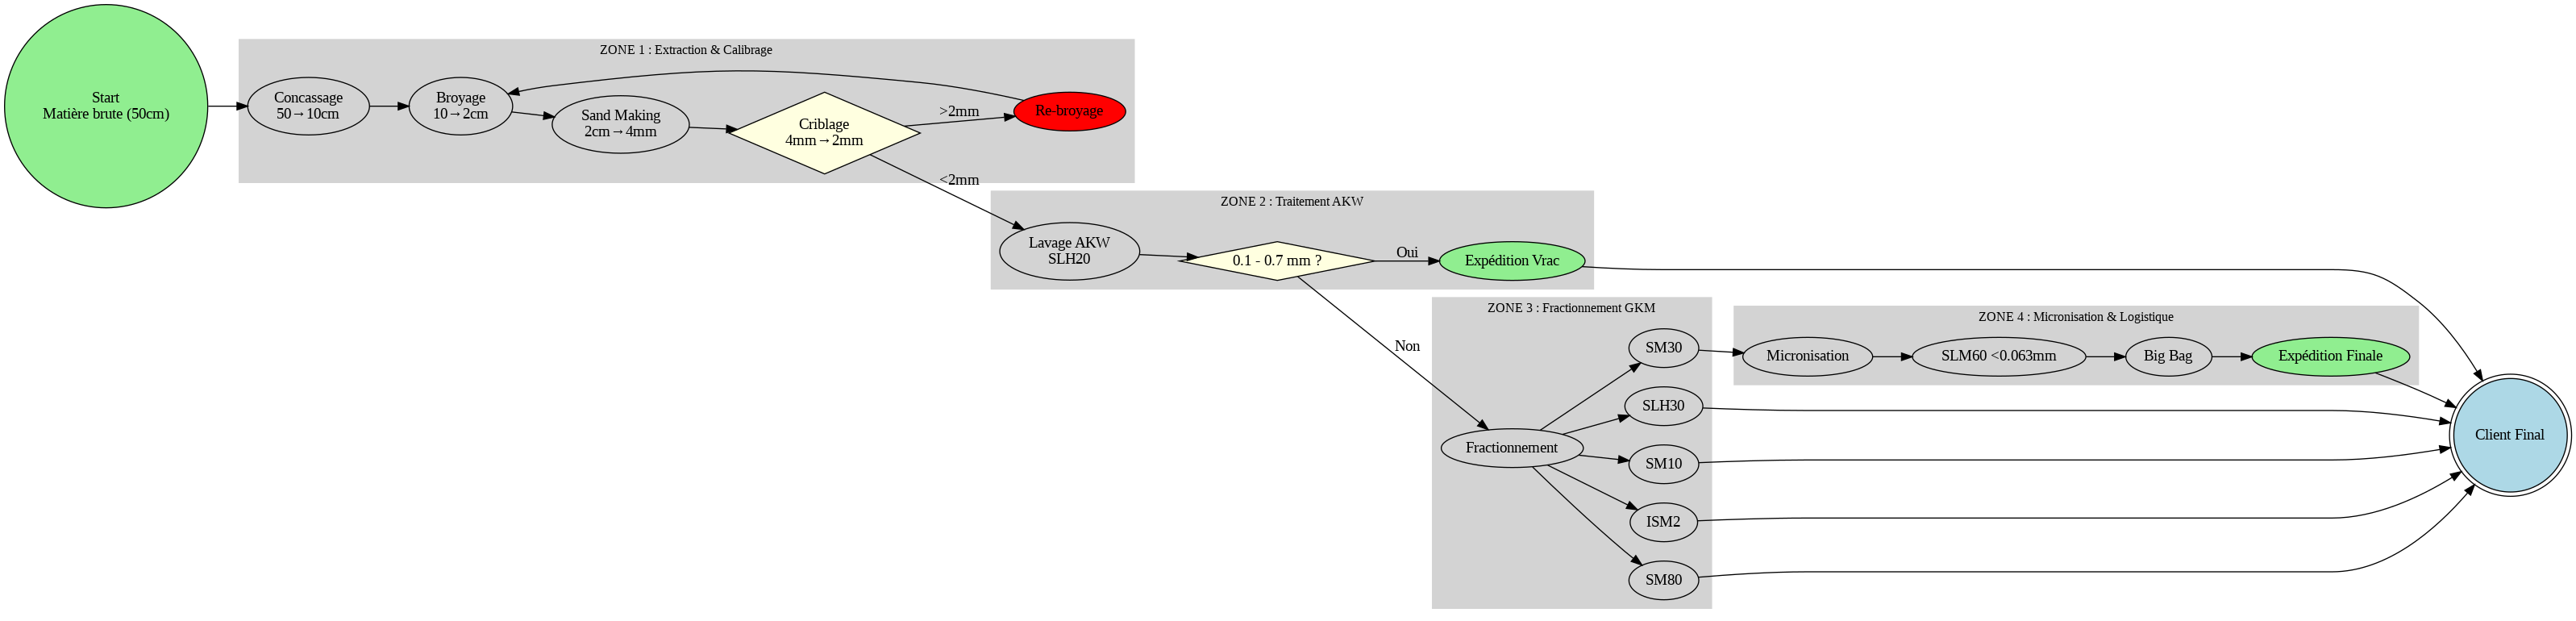

In [ ]:
# Génération
bpmn.render('BPMN_Traspex', view=False)

# Affichage dans Colab
from IPython.display import Image, display
display(Image('BPMN_Traspex.png'))

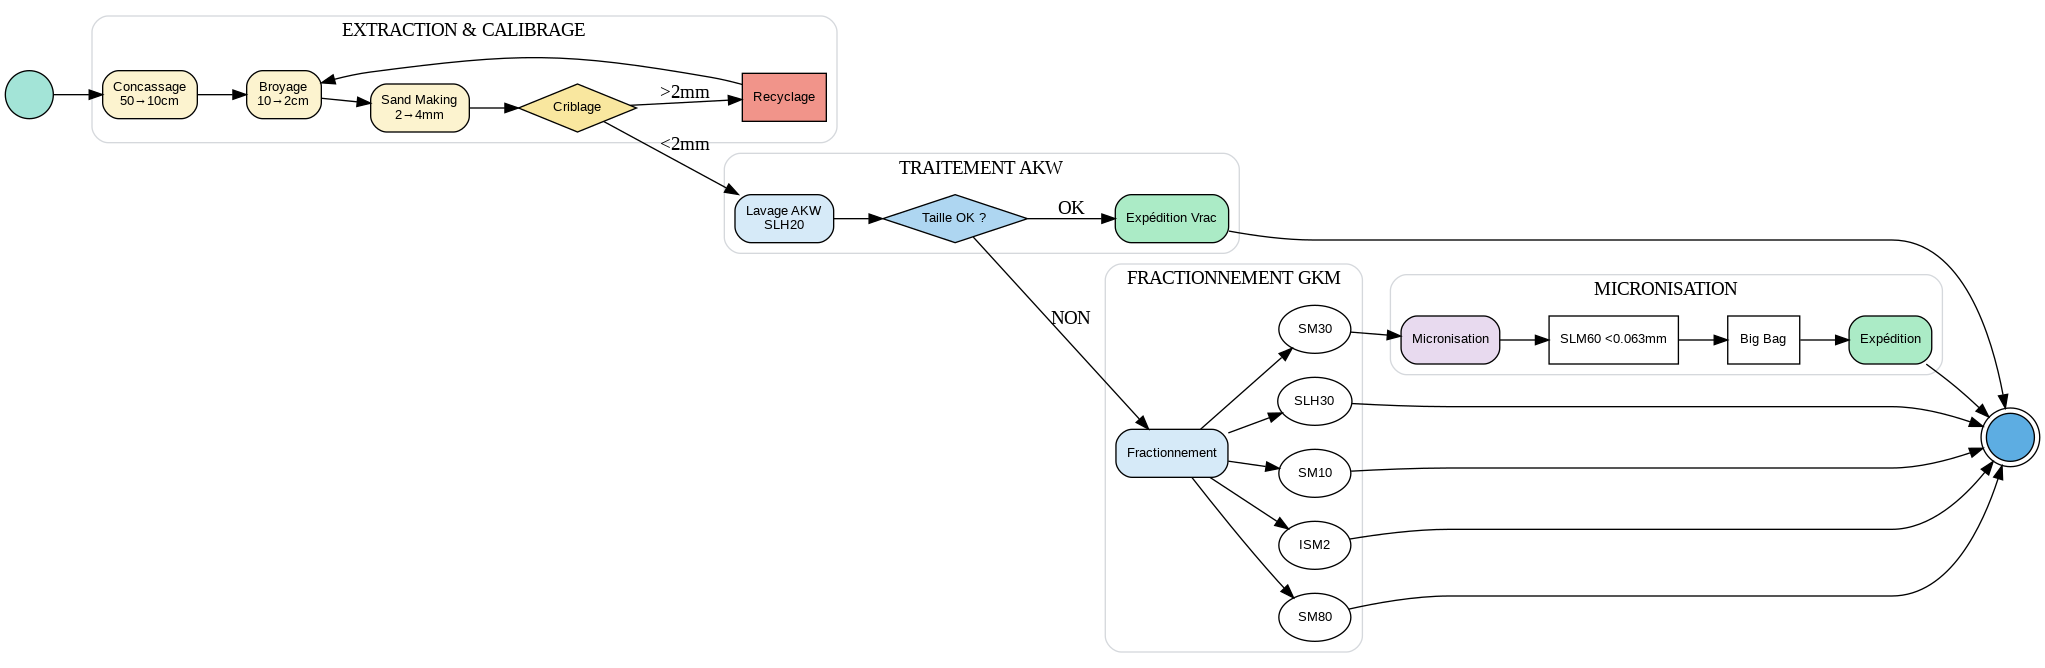

In [ ]:
from graphviz import Digraph
from IPython.display import Image, display

bpmn = Digraph('BPMN_Pro', format='png')
bpmn.attr(rankdir='LR', bgcolor='white')

# Style général
bpmn.attr('node', fontname='Helvetica', fontsize='10')

# 🔵 START / END
bpmn.node('Start', '', shape='circle', style='filled', fillcolor='#A3E4D7')
bpmn.node('End', '', shape='doublecircle', style='filled', fillcolor='#5DADE2')

# =========================
# 🟡 PHASE 1
# =========================
with bpmn.subgraph(name='cluster1') as c:
    c.attr(label='EXTRACTION & CALIBRAGE', style='rounded', color='#D5D8DC')

    c.node('C1', 'Concassage\n50→10cm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('B2', 'Broyage\n10→2cm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('SMM3', 'Sand Making\n2→4mm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('Crib', 'Criblage', shape='diamond', style='filled', fillcolor='#F9E79F')
    c.node('Rejet', 'Recyclage', shape='box', style='filled', fillcolor='#F1948A')

# =========================
# 🟠 PHASE 2
# =========================
with bpmn.subgraph(name='cluster2') as c:
    c.attr(label='TRAITEMENT AKW', style='rounded', color='#D5D8DC')

    c.node('AKW', 'Lavage AKW\nSLH20', shape='box', style='rounded,filled', fillcolor='#D6EAF8')
    c.node('DecAKW', 'Taille OK ?', shape='diamond', style='filled', fillcolor='#AED6F1')
    c.node('ExpVrac', 'Expédition Vrac', shape='box', style='rounded,filled', fillcolor='#ABEBC6')

# =========================
# 🔵 PHASE 3
# =========================
with bpmn.subgraph(name='cluster3') as c:
    c.attr(label='FRACTIONNEMENT GKM', style='rounded', color='#D5D8DC')

    c.node('GKM', 'Fractionnement', shape='box', style='rounded,filled', fillcolor='#D6EAF8')

    c.node('SLH30', 'SLH30')
    c.node('SM10', 'SM10')
    c.node('ISM2', 'ISM2')
    c.node('SM80', 'SM80')
    c.node('SM30', 'SM30')

# =========================
# 🟣 PHASE 4
# =========================
with bpmn.subgraph(name='cluster4') as c:
    c.attr(label='MICRONISATION', style='rounded', color='#D5D8DC')

    c.node('Micro', 'Micronisation', shape='box', style='rounded,filled', fillcolor='#E8DAEF')
    c.node('SLM60', 'SLM60 <0.063mm', shape='box')
    c.node('BigBag', 'Big Bag', shape='box')
    c.node('ExpFinal', 'Expédition', shape='box', style='rounded,filled', fillcolor='#ABEBC6')

# =========================
# 🔗 FLOW
# =========================
bpmn.edge('Start', 'C1')

bpmn.edge('C1', 'B2')
bpmn.edge('B2', 'SMM3')
bpmn.edge('SMM3', 'Crib')

bpmn.edge('Crib', 'Rejet', label='>2mm')
bpmn.edge('Rejet', 'B2')
bpmn.edge('Crib', 'AKW', label='<2mm')

bpmn.edge('AKW', 'DecAKW')
bpmn.edge('DecAKW', 'ExpVrac', label='OK')
bpmn.edge('DecAKW', 'GKM', label='NON')

bpmn.edge('GKM', 'SLH30')
bpmn.edge('GKM', 'SM10')
bpmn.edge('GKM', 'ISM2')
bpmn.edge('GKM', 'SM80')
bpmn.edge('GKM', 'SM30')

bpmn.edge('SLH30', 'End')
bpmn.edge('SM10', 'End')
bpmn.edge('ISM2', 'End')
bpmn.edge('SM80', 'End')

bpmn.edge('SM30', 'Micro')
bpmn.edge('Micro', 'SLM60')
bpmn.edge('SLM60', 'BigBag')
bpmn.edge('BigBag', 'ExpFinal')
bpmn.edge('ExpFinal', 'End')

bpmn.edge('ExpVrac', 'End')

# Génération + affichage
bpmn.render('BPMN_Pro', view=False)
display(Image('BPMN_Pro.png'))

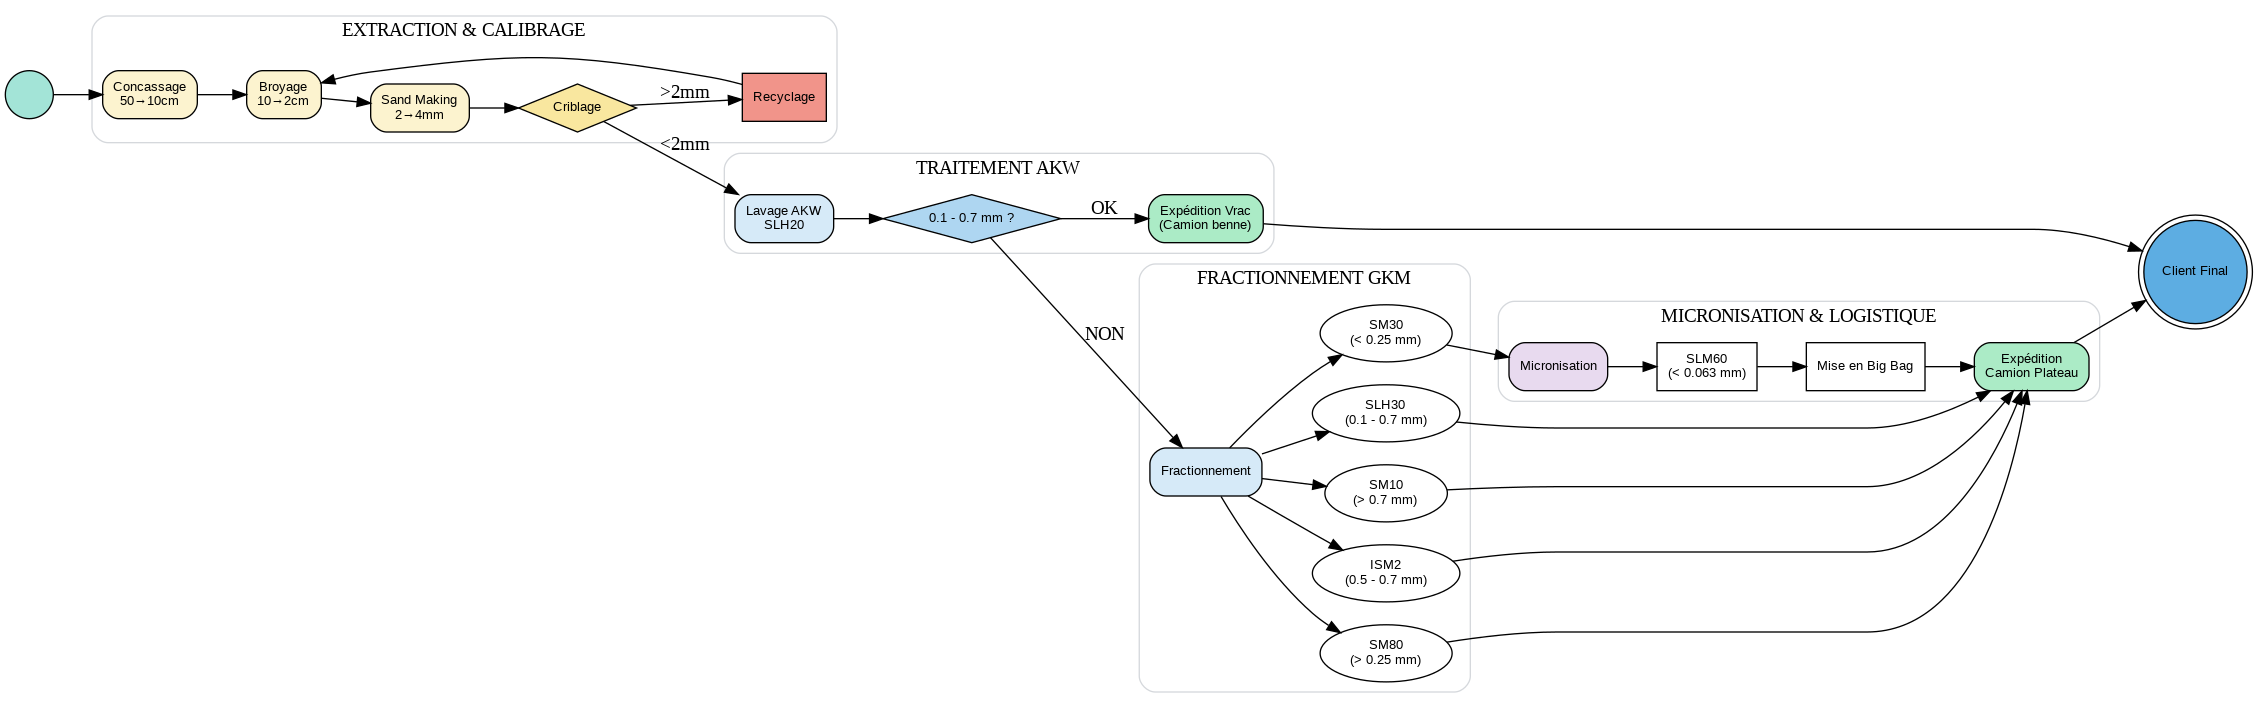

In [ ]:
from graphviz import Digraph
from IPython.display import Image, display

bpmn = Digraph('BPMN_Pro_Final', format='png')
bpmn.attr(rankdir='LR', bgcolor='white')

bpmn.attr('node', fontname='Helvetica', fontsize='10')

# START / END
bpmn.node('Start', '', shape='circle', style='filled', fillcolor='#A3E4D7')
bpmn.node('End', 'Client Final', shape='doublecircle', style='filled', fillcolor='#5DADE2')

# =========================
# PHASE 1
# =========================
with bpmn.subgraph(name='cluster1') as c:
    c.attr(label='EXTRACTION & CALIBRAGE', style='rounded', color='#D5D8DC')

    c.node('C1', 'Concassage\n50→10cm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('B2', 'Broyage\n10→2cm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('SMM3', 'Sand Making\n2→4mm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('Crib', 'Criblage', shape='diamond', style='filled', fillcolor='#F9E79F')
    c.node('Rejet', 'Recyclage', shape='box', style='filled', fillcolor='#F1948A')

# =========================
# PHASE 2
# =========================
with bpmn.subgraph(name='cluster2') as c:
    c.attr(label='TRAITEMENT AKW', style='rounded', color='#D5D8DC')

    c.node('AKW', 'Lavage AKW\nSLH20', shape='box', style='rounded,filled', fillcolor='#D6EAF8')
    c.node('DecAKW', '0.1 - 0.7 mm ?', shape='diamond', style='filled', fillcolor='#AED6F1')
    c.node('ExpVrac', 'Expédition Vrac\n(Camion benne)', shape='box', style='rounded,filled', fillcolor='#ABEBC6')

# =========================
# PHASE 3
# =========================
with bpmn.subgraph(name='cluster3') as c:
    c.attr(label='FRACTIONNEMENT GKM', style='rounded', color='#D5D8DC')

    c.node('GKM', 'Fractionnement', shape='box', style='rounded,filled', fillcolor='#D6EAF8')

    c.node('SLH30', 'SLH30\n(0.1 - 0.7 mm)')
    c.node('SM10', 'SM10\n(> 0.7 mm)')
    c.node('ISM2', 'ISM2\n(0.5 - 0.7 mm)')
    c.node('SM80', 'SM80\n(> 0.25 mm)')
    c.node('SM30', 'SM30\n(< 0.25 mm)')

# =========================
# PHASE 4
# =========================
with bpmn.subgraph(name='cluster4') as c:
    c.attr(label='MICRONISATION & LOGISTIQUE', style='rounded', color='#D5D8DC')

    c.node('Micro', 'Micronisation', shape='box', style='rounded,filled', fillcolor='#E8DAEF')
    c.node('SLM60', 'SLM60\n(< 0.063 mm)', shape='box')
    c.node('BigBag', 'Mise en Big Bag', shape='box')

    # 🔥 point logistique commun
    c.node('ExpPlateau', 'Expédition\nCamion Plateau', shape='box', style='rounded,filled', fillcolor='#ABEBC6')

# =========================
# FLOW
# =========================
bpmn.edge('Start', 'C1')
bpmn.edge('C1', 'B2')
bpmn.edge('B2', 'SMM3')
bpmn.edge('SMM3', 'Crib')

bpmn.edge('Crib', 'Rejet', label='>2mm')
bpmn.edge('Rejet', 'B2')
bpmn.edge('Crib', 'AKW', label='<2mm')

bpmn.edge('AKW', 'DecAKW')
bpmn.edge('DecAKW', 'ExpVrac', label='OK')
bpmn.edge('DecAKW', 'GKM', label='NON')

# GKM vers produits
bpmn.edge('GKM', 'SLH30')
bpmn.edge('GKM', 'SM10')
bpmn.edge('GKM', 'ISM2')
bpmn.edge('GKM', 'SM80')
bpmn.edge('GKM', 'SM30')

# 🔥 tous les produits vers expédition plateau
bpmn.edge('SLH30', 'ExpPlateau')
bpmn.edge('SM10', 'ExpPlateau')
bpmn.edge('ISM2', 'ExpPlateau')
bpmn.edge('SM80', 'ExpPlateau')

# Micronisation
bpmn.edge('SM30', 'Micro')
bpmn.edge('Micro', 'SLM60')
bpmn.edge('SLM60', 'BigBag')
bpmn.edge('BigBag', 'ExpPlateau')

# Sorties finales
bpmn.edge('ExpPlateau', 'End')
bpmn.edge('ExpVrac', 'End')

# Génération
bpmn.render('BPMN_Final', view=False)
display(Image('BPMN_Final.png'))

In [ ]:
bpmn.node('Start', 'Extraction de sable brut\n(blocs rocheux ~50 cm)',
          shape='circle', style='filled', fillcolor='#A3E4D7')

In [ ]:
bpmn.node('Start', 'Début\nExtraction sable brut\n(~50 cm blocs)',
          shape='circle', style='filled', fillcolor='#A3E4D7')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


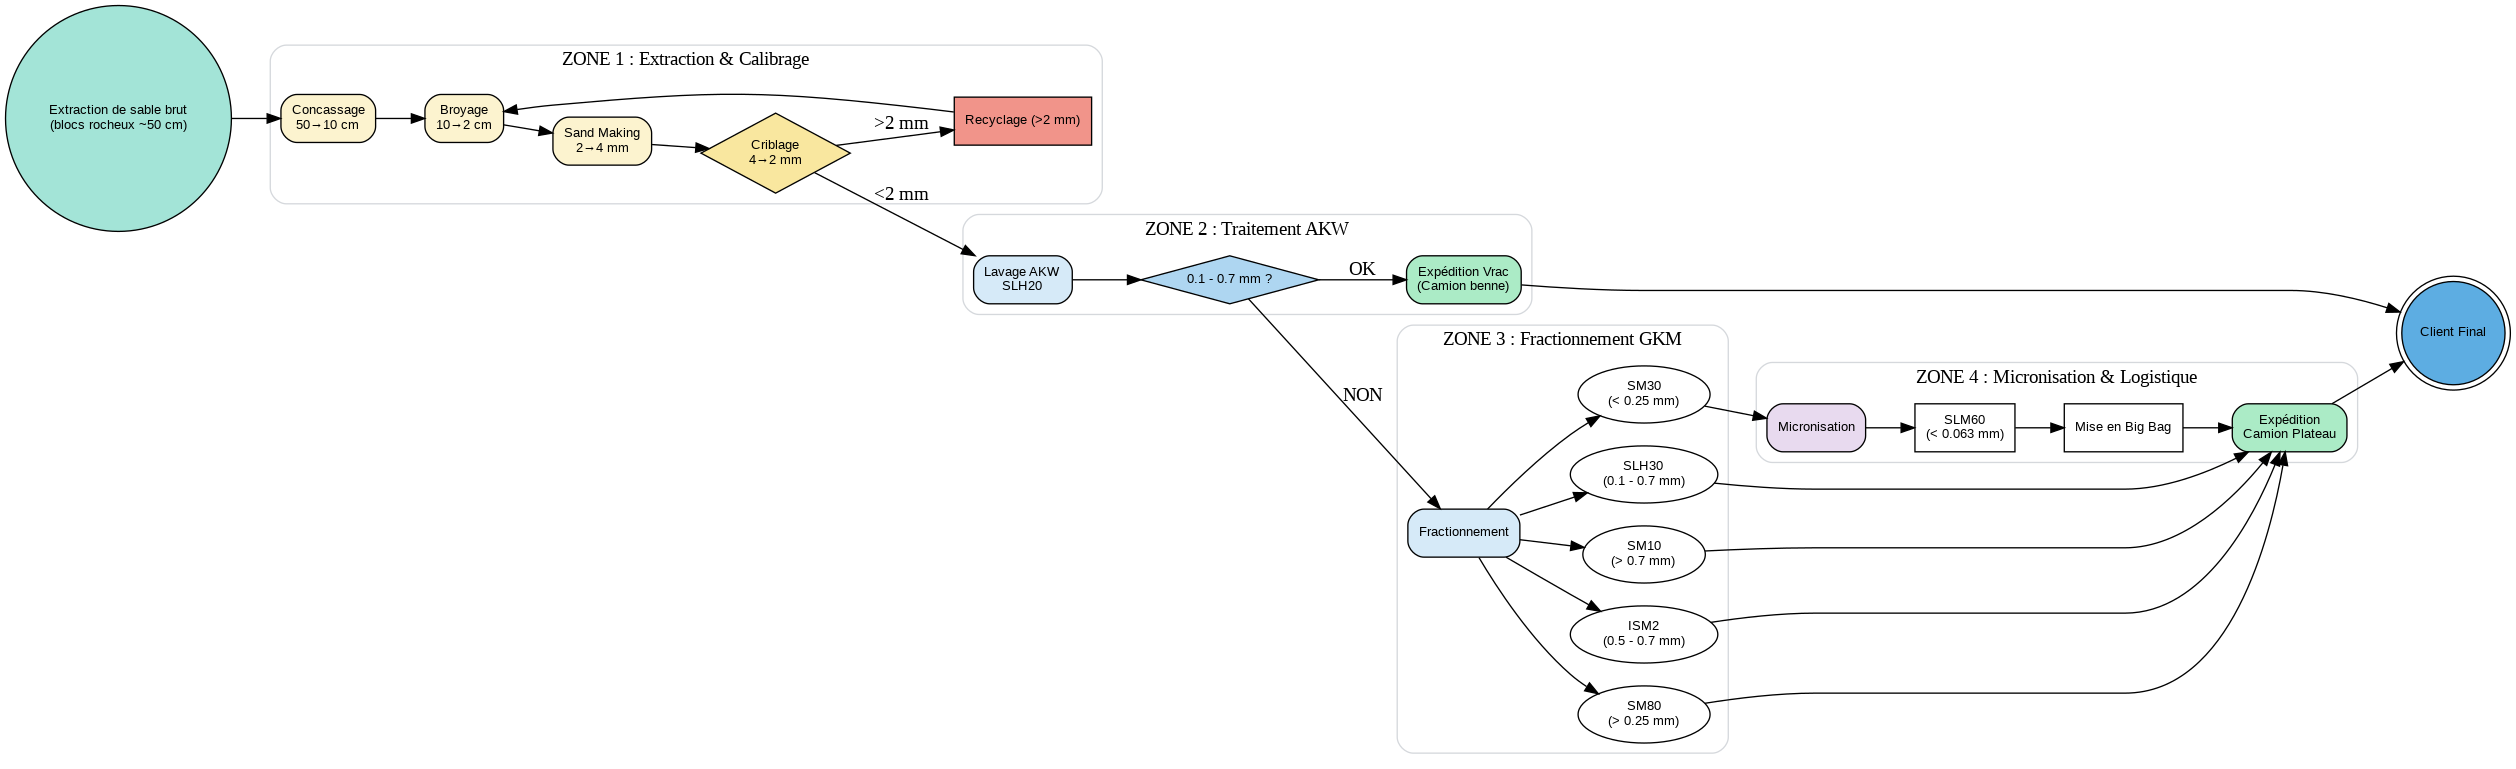

In [ ]:
# Installer Graphviz (à exécuter une seule fois sur Colab)
!apt-get install graphviz -y
!pip install graphviz

from graphviz import Digraph
from IPython.display import Image, display

# Création du diagramme
bpmn = Digraph('BPMN_Traspex_Final', format='png')
bpmn.attr(rankdir='LR', bgcolor='white')
bpmn.attr('node', fontname='Helvetica', fontsize='10')

# =========================
# 🔵 START / END
# =========================
bpmn.node('Start', 'Extraction de sable brut\n(blocs rocheux ~50 cm)',
          shape='circle', style='filled', fillcolor='#A3E4D7')

bpmn.node('End', 'Client Final',
          shape='doublecircle', style='filled', fillcolor='#5DADE2')

# =========================
# 🟡 PHASE 1 : EXTRACTION
# =========================
with bpmn.subgraph(name='cluster1') as c:
    c.attr(label='ZONE 1 : Extraction & Calibrage', style='rounded', color='#D5D8DC')

    c.node('C1', 'Concassage\n50→10 cm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('B2', 'Broyage\n10→2 cm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('SMM3', 'Sand Making\n2→4 mm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('Crib', 'Criblage\n4→2 mm', shape='diamond', style='filled', fillcolor='#F9E79F')
    c.node('Rejet', 'Recyclage (>2 mm)', shape='box', style='filled', fillcolor='#F1948A')

# =========================
# 🟠 PHASE 2 : AKW
# =========================
with bpmn.subgraph(name='cluster2') as c:
    c.attr(label='ZONE 2 : Traitement AKW', style='rounded', color='#D5D8DC')

    c.node('AKW', 'Lavage AKW\nSLH20', shape='box', style='rounded,filled', fillcolor='#D6EAF8')
    c.node('DecAKW', '0.1 - 0.7 mm ?', shape='diamond', style='filled', fillcolor='#AED6F1')
    c.node('ExpVrac', 'Expédition Vrac\n(Camion benne)', shape='box', style='rounded,filled', fillcolor='#ABEBC6')

# =========================
# 🔵 PHASE 3 : GKM
# =========================
with bpmn.subgraph(name='cluster3') as c:
    c.attr(label='ZONE 3 : Fractionnement GKM', style='rounded', color='#D5D8DC')

    c.node('GKM', 'Fractionnement', shape='box', style='rounded,filled', fillcolor='#D6EAF8')

    c.node('SLH30', 'SLH30\n(0.1 - 0.7 mm)')
    c.node('SM10', 'SM10\n(> 0.7 mm)')
    c.node('ISM2', 'ISM2\n(0.5 - 0.7 mm)')
    c.node('SM80', 'SM80\n(> 0.25 mm)')
    c.node('SM30', 'SM30\n(< 0.25 mm)')

# =========================
# 🟣 PHASE 4 : MICRONISATION
# =========================
with bpmn.subgraph(name='cluster4') as c:
    c.attr(label='ZONE 4 : Micronisation & Logistique', style='rounded', color='#D5D8DC')

    c.node('Micro', 'Micronisation', shape='box', style='rounded,filled', fillcolor='#E8DAEF')
    c.node('SLM60', 'SLM60\n(< 0.063 mm)', shape='box')
    c.node('BigBag', 'Mise en Big Bag', shape='box')

    # Point logistique commun
    c.node('ExpPlateau', 'Expédition\nCamion Plateau',
           shape='box', style='rounded,filled', fillcolor='#ABEBC6')

# =========================
# 🔗 FLUX
# =========================
bpmn.edge('Start', 'C1')
bpmn.edge('C1', 'B2')
bpmn.edge('B2', 'SMM3')
bpmn.edge('SMM3', 'Crib')

# Décision criblage
bpmn.edge('Crib', 'Rejet', label='>2 mm')
bpmn.edge('Rejet', 'B2')
bpmn.edge('Crib', 'AKW', label='<2 mm')

# AKW
bpmn.edge('AKW', 'DecAKW')
bpmn.edge('DecAKW', 'ExpVrac', label='OK')
bpmn.edge('DecAKW', 'GKM', label='NON')

# GKM produits
bpmn.edge('GKM', 'SLH30')
bpmn.edge('GKM', 'SM10')
bpmn.edge('GKM', 'ISM2')
bpmn.edge('GKM', 'SM80')
bpmn.edge('GKM', 'SM30')

# Tous vers expédition plateau
bpmn.edge('SLH30', 'ExpPlateau')
bpmn.edge('SM10', 'ExpPlateau')
bpmn.edge('ISM2', 'ExpPlateau')
bpmn.edge('SM80', 'ExpPlateau')

# Micronisation
bpmn.edge('SM30', 'Micro')
bpmn.edge('Micro', 'SLM60')
bpmn.edge('SLM60', 'BigBag')
bpmn.edge('BigBag', 'ExpPlateau')

# Sorties finales
bpmn.edge('ExpPlateau', 'End')
bpmn.edge('ExpVrac', 'End')

# =========================
# 📊 GENERATION + AFFICHAGE
# =========================
bpmn.render('BPMN_Traspex_Final', view=False)
display(Image('BPMN_Traspex_Final.png'))

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


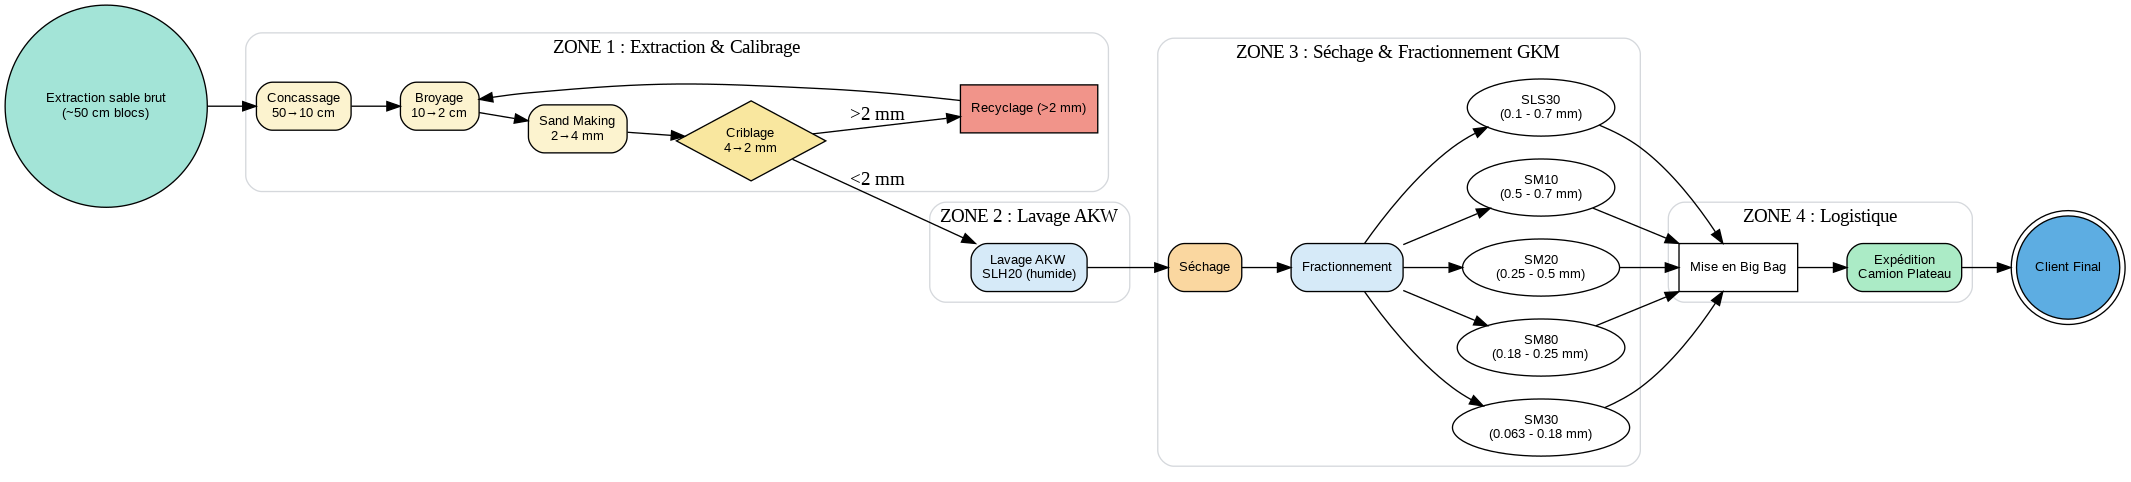

In [1]:
# Installer Graphviz (une seule fois)
!apt-get install graphviz -y
!pip install graphviz

from graphviz import Digraph
from IPython.display import Image, display

bpmn = Digraph('BPMN_Traspex_New', format='png')
bpmn.attr(rankdir='LR', bgcolor='white')
bpmn.attr('node', fontname='Helvetica', fontsize='10')

# =========================
# START / END
# =========================
bpmn.node('Start', 'Extraction sable brut\n(~50 cm blocs)',
          shape='circle', style='filled', fillcolor='#A3E4D7')

bpmn.node('End', 'Client Final',
          shape='doublecircle', style='filled', fillcolor='#5DADE2')

# =========================
# PHASE 1 : EXTRACTION
# =========================
with bpmn.subgraph(name='cluster1') as c:
    c.attr(label='ZONE 1 : Extraction & Calibrage', style='rounded', color='#D5D8DC')

    c.node('C1', 'Concassage\n50→10 cm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('B2', 'Broyage\n10→2 cm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('SMM3', 'Sand Making\n2→4 mm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('Crib', 'Criblage\n4→2 mm', shape='diamond', style='filled', fillcolor='#F9E79F')
    c.node('Rejet', 'Recyclage (>2 mm)', shape='box', style='filled', fillcolor='#F1948A')

# =========================
# PHASE 2 : AKW
# =========================
with bpmn.subgraph(name='cluster2') as c:
    c.attr(label='ZONE 2 : Lavage AKW', style='rounded', color='#D5D8DC')

    c.node('AKW', 'Lavage AKW\nSLH20 (humide)',
           shape='box', style='rounded,filled', fillcolor='#D6EAF8')

# =========================
# PHASE 3 : GKM + SECHAGE
# =========================
with bpmn.subgraph(name='cluster3') as c:
    c.attr(label='ZONE 3 : Séchage & Fractionnement GKM', style='rounded', color='#D5D8DC')

    c.node('Sechage', 'Séchage', shape='box', style='rounded,filled', fillcolor='#FAD7A0')
    c.node('GKM', 'Fractionnement', shape='box', style='rounded,filled', fillcolor='#D6EAF8')

    # Produits avec mesures
    c.node('SLS30', 'SLS30\n(0.1 - 0.7 mm)')
    c.node('SM10', 'SM10\n(0.5 - 0.7 mm)')
    c.node('SM20', 'SM20\n(0.25 - 0.5 mm)')
    c.node('SM80', 'SM80\n(0.18 - 0.25 mm)')
    c.node('SM30', 'SM30\n(0.063 - 0.18 mm)')

# =========================
# PHASE 4 : LOGISTIQUE
# =========================
with bpmn.subgraph(name='cluster4') as c:
    c.attr(label='ZONE 4 : Logistique', style='rounded', color='#D5D8DC')

    c.node('BigBag', 'Mise en Big Bag', shape='box')
    c.node('ExpPlateau', 'Expédition\nCamion Plateau',
           shape='box', style='rounded,filled', fillcolor='#ABEBC6')

# =========================
# FLOW
# =========================
bpmn.edge('Start', 'C1')
bpmn.edge('C1', 'B2')
bpmn.edge('B2', 'SMM3')
bpmn.edge('SMM3', 'Crib')

bpmn.edge('Crib', 'Rejet', label='>2 mm')
bpmn.edge('Rejet', 'B2')
bpmn.edge('Crib', 'AKW', label='<2 mm')

# Vers séchage
bpmn.edge('AKW', 'Sechage')

# Fractionnement
bpmn.edge('Sechage', 'GKM')

bpmn.edge('GKM', 'SLS30')
bpmn.edge('GKM', 'SM10')
bpmn.edge('GKM', 'SM20')
bpmn.edge('GKM', 'SM80')
bpmn.edge('GKM', 'SM30')

# Logistique
bpmn.edge('SLS30', 'BigBag')
bpmn.edge('SM10', 'BigBag')
bpmn.edge('SM20', 'BigBag')
bpmn.edge('SM80', 'BigBag')
bpmn.edge('SM30', 'BigBag')

bpmn.edge('BigBag', 'ExpPlateau')
bpmn.edge('ExpPlateau', 'End')

# =========================
# GENERATION
# =========================
bpmn.render('BPMN_Traspex_Updated', view=False)
display(Image('BPMN_Traspex_Updated.png'))

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


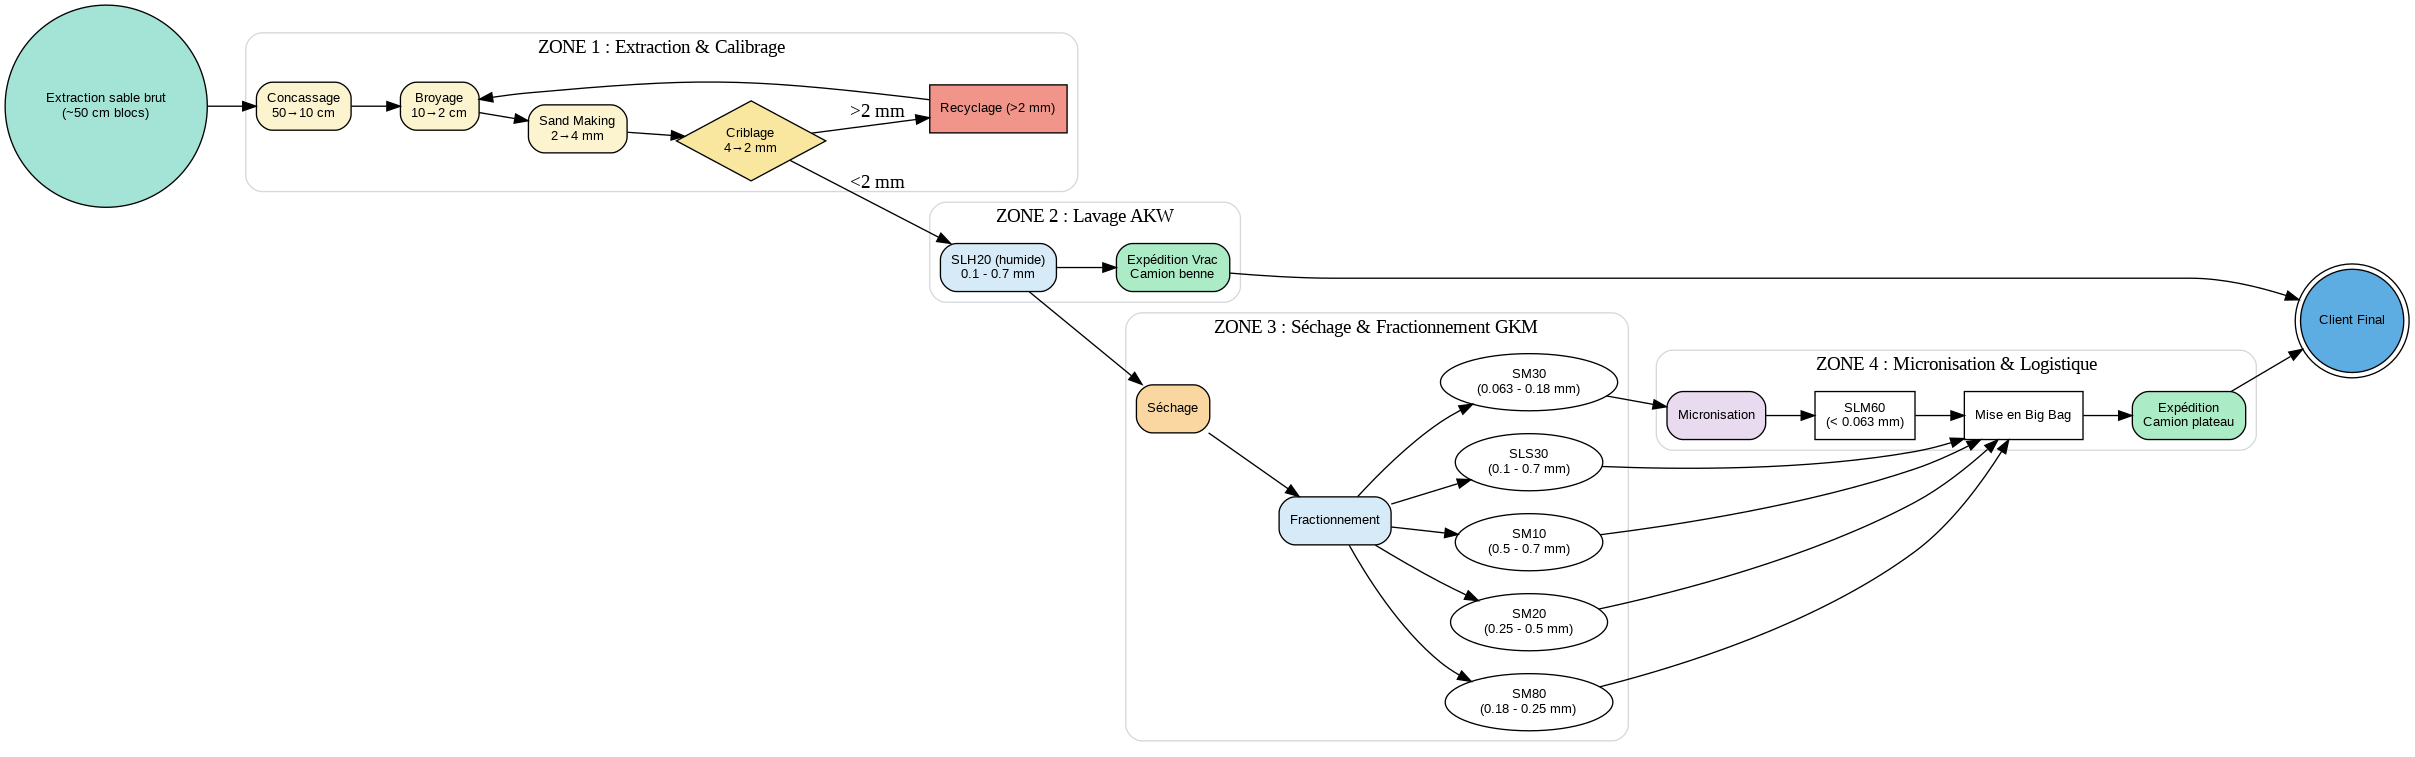

In [2]:
# Installer Graphviz (une seule fois)
!apt-get install graphviz -y
!pip install graphviz

from graphviz import Digraph
from IPython.display import Image, display

bpmn = Digraph('BPMN_Traspex_Final_Pro', format='png')
bpmn.attr(rankdir='LR', bgcolor='white')
bpmn.attr('node', fontname='Helvetica', fontsize='10')

# =========================
# START / END
# =========================
bpmn.node('Start', 'Extraction sable brut\n(~50 cm blocs)',
          shape='circle', style='filled', fillcolor='#A3E4D7')

bpmn.node('End', 'Client Final',
          shape='doublecircle', style='filled', fillcolor='#5DADE2')

# =========================
# PHASE 1 : EXTRACTION
# =========================
with bpmn.subgraph(name='cluster1') as c:
    c.attr(label='ZONE 1 : Extraction & Calibrage', style='rounded', color='#D5D8DC')

    c.node('C1', 'Concassage\n50→10 cm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('B2', 'Broyage\n10→2 cm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('SMM3', 'Sand Making\n2→4 mm', shape='box', style='rounded,filled', fillcolor='#FCF3CF')
    c.node('Crib', 'Criblage\n4→2 mm', shape='diamond', style='filled', fillcolor='#F9E79F')
    c.node('Rejet', 'Recyclage (>2 mm)', shape='box', style='filled', fillcolor='#F1948A')

# =========================
# PHASE 2 : AKW
# =========================
with bpmn.subgraph(name='cluster2') as c:
    c.attr(label='ZONE 2 : Lavage AKW', style='rounded', color='#D5D8DC')

    c.node('AKW', 'SLH20 (humide)\n0.1 - 0.7 mm',
           shape='box', style='rounded,filled', fillcolor='#D6EAF8')

    c.node('ExpVrac', 'Expédition Vrac\nCamion benne',
           shape='box', style='rounded,filled', fillcolor='#ABEBC6')

# =========================
# PHASE 3 : SECHAGE + GKM
# =========================
with bpmn.subgraph(name='cluster3') as c:
    c.attr(label='ZONE 3 : Séchage & Fractionnement GKM', style='rounded', color='#D5D8DC')

    c.node('Sechage', 'Séchage', shape='box', style='rounded,filled', fillcolor='#FAD7A0')
    c.node('GKM', 'Fractionnement', shape='box', style='rounded,filled', fillcolor='#D6EAF8')

    c.node('SLS30', 'SLS30\n(0.1 - 0.7 mm)')
    c.node('SM10', 'SM10\n(0.5 - 0.7 mm)')
    c.node('SM20', 'SM20\n(0.25 - 0.5 mm)')
    c.node('SM80', 'SM80\n(0.18 - 0.25 mm)')
    c.node('SM30', 'SM30\n(0.063 - 0.18 mm)')

# =========================
# PHASE 4 : MICRONISATION
# =========================
with bpmn.subgraph(name='cluster4') as c:
    c.attr(label='ZONE 4 : Micronisation & Logistique', style='rounded', color='#D5D8DC')

    c.node('Micro', 'Micronisation', shape='box', style='rounded,filled', fillcolor='#E8DAEF')
    c.node('SLM60', 'SLM60\n(< 0.063 mm)', shape='box')

    c.node('BigBag', 'Mise en Big Bag', shape='box')
    c.node('ExpPlateau', 'Expédition\nCamion plateau',
           shape='box', style='rounded,filled', fillcolor='#ABEBC6')

# =========================
# FLOW
# =========================
bpmn.edge('Start', 'C1')
bpmn.edge('C1', 'B2')
bpmn.edge('B2', 'SMM3')
bpmn.edge('SMM3', 'Crib')

bpmn.edge('Crib', 'Rejet', label='>2 mm')
bpmn.edge('Rejet', 'B2')
bpmn.edge('Crib', 'AKW', label='<2 mm')

# 🔥 SLH20 expédition directe
bpmn.edge('AKW', 'ExpVrac')
bpmn.edge('ExpVrac', 'End')

# 🔽 Vers séchage
bpmn.edge('AKW', 'Sechage')

# Fractionnement
bpmn.edge('Sechage', 'GKM')

bpmn.edge('GKM', 'SLS30')
bpmn.edge('GKM', 'SM10')
bpmn.edge('GKM', 'SM20')
bpmn.edge('GKM', 'SM80')
bpmn.edge('GKM', 'SM30')

# Vers BigBag
bpmn.edge('SLS30', 'BigBag')
bpmn.edge('SM10', 'BigBag')
bpmn.edge('SM20', 'BigBag')
bpmn.edge('SM80', 'BigBag')

# 🔥 Micronisation
bpmn.edge('SM30', 'Micro')
bpmn.edge('Micro', 'SLM60')
bpmn.edge('SLM60', 'BigBag')

# Expédition finale
bpmn.edge('BigBag', 'ExpPlateau')
bpmn.edge('ExpPlateau', 'End')

# =========================
# GENERATION
# =========================
bpmn.render('BPMN_Traspex_FINAL', view=False)
display(Image('BPMN_Traspex_FINAL.png'))